# 02 — Modelado Supervisado: Clasificación de Deserción y Rendimiento (CRISP-DM: fases 4–5)

## Definición del Problema
En esta etapa abordaremos una tarea de **Clasificación Supervisada**. Nuestra variable objetivo ($y$) será predecir el estado académico o riesgo de deserción del estudiante (utilizando la variable de estado de matrícula). Las variables predictoras ($X$) estarán conformadas por métricas académicas continuas, tales como el total de ausencias y el promedio de notas.

## Objetivos
1. Dividir los datos en subconjuntos de Entrenamiento (80%) y Prueba (20%).
2. Escalar los datos para asegurar la correcta convergencia de los modelos numéricos.
3. Entrenar de forma competitiva 3 algoritmos de naturaleza distinta (ej. Logistic Regression, SVC, Random Forest).
4. Comparar su precisión (`Accuracy`) y puntuación F1 (`F1-Score`), diagnosticando posibles problemas de generalización.
5. Visualizar matrices de confusión estandarizadas.

In [1]:
%load_ext kedro.ipython

[05/12/26 23:30:30] INFO     Using                                                                  ]8;id=1479917;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=1479918;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/py                
                             thon3.13/site-packages/kedro/framework/project/rich_logging.yml' as                   
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=1479925;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=1479926;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=1479932;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=1479933;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=1479939;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=1479940;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe.                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/12/26 23:30:30] INFO     No typed parameter requirements found, returning original   ]8;id=1479947;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=1479948;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=1479955;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=1479956;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/12/26 23:30:31] INFO     Kedro project ev_parcial1_uribe                                        ]8;id=1479962;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=1479963;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=1479969;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=1479970;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# Solución robusta: si Jupyter se abre dentro de la carpeta /notebooks
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"
assert (PROJECT_ROOT / "pyproject.toml").is_file(), (
    "Abre este notebook desde la raíz del proyecto con `kedro jupyter lab`."
)
assert DATA_PATH.is_file(), (
    f"No existe el archivo {DATA_PATH}. Ejecuta el pipeline previo para generarlo."
)
print(f"Proyecto: {PROJECT_ROOT}")
print(f"Datos: {DATA_PATH}")

Proyecto: /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe
Datos: /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/data/03_primary/tabla_maestra.csv


## 1. Preparación de Datos (Train/Test Split y Escalado)

### Justificación Técnica
Para evaluar correctamente la capacidad predictiva y prevenir el *Overfitting* (sobreajuste), aislamos el 20% de los registros estadísticos como conjunto de prueba (unseen data).

Además, integramos un escalado de estandarización (`StandardScaler`) a la matriz de características numéricas. Esto es **vital** para algoritmos matemáticos dependientes de distancias euclidianas y cálculos de gradientes (como la Regresión Logística y las Máquinas de Vectores de Soporte). Sin este paso, las variables con escalas grandes (ej. porcentaje de asistencia 0-100) opacarían estadísticamente a las de escalas pequeñas (ej. notas 1.0-7.0).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

# Carga de datos
df = pd.read_csv(DATA_PATH)

# Definir variables predictoras (Features) y objetivo (Target)
feat_cols = ["total_ausencias", "promedio_notas"]
target_col = "estado_matricula"

# Filtrar nulos estrictamente para no entrenar con ruido en el target
df_ml = df.dropna(subset=feat_cols + [target_col]).copy()

X = df_ml[feat_cols]
y = df_ml[target_col]

# Train/Test Split (80% / 20%) con estratificación (stratify) para garantizar 
# proporciones equitativas de deserción en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Datos de Entrenamiento (Train): {len(X_train):,} estudiantes")
print(f"Datos de Evaluación (Test): {len(X_test):,} estudiantes")

Datos de Entrenamiento (Train): 508 estudiantes
Datos de Evaluación (Test): 128 estudiantes


## 2. Entrenamiento Multimodelo

Desarrollaremos 3 modelos basados en arquitecturas completamente distintas para observar sus beneficios particulares en el conjunto de prueba:
- **Logistic Regression:** Enfoque probabilístico lineal tradicional.
- **Support Vector Classifier (SVC):** Optimización geométrica mediante hiperplanos.
- **Random Forest Classifier:** Enfoque no lineal, fundamentado en ensamblaje de múltiples árboles de decisión.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# Construcción técnica basada en Pipelines (garantiza evitar el data leakage del escalado)
models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVC": Pipeline([
        ("scale", StandardScaler()),
        ("clf", SVC(kernel="linear", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scale", StandardScaler()), # Para mantener consistencia estructural
        ("clf", RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1))
    ])
}

resultados_list = []
fitted_models = {}
predictions = {}

for name, model_pipeline in models.items():
    # Fase Fit
    model_pipeline.fit(X_train, y_train)
    
    # Fase Predict
    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)
    
    fitted_models[name] = model_pipeline
    predictions[name] = y_pred_test
    
    # Extracción de Métricas Críticas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, average="weighted")
    
    resultados_list.append({
        "Modelo": name,
        "Train_Accuracy": acc_train,
        "Test_Accuracy": acc_test,
        "Test_F1_Weighted": f1_test
    })

resultados_df = pd.DataFrame(resultados_list).sort_values(by="Test_F1_Weighted", ascending=False).reset_index(drop=True)
resultados_df

,Modelo,Train_Accuracy,Test_Accuracy,Test_F1_Weighted
0,Random Forest,0.622047,0.617188,0.486848
1,Logistic Regression,0.614173,0.617188,0.471090
2,SVC,0.614173,0.617188,0.471090


## 3. Evaluación Comparativa (Classification Report)

Un Accuracy alto no siempre es sinónimo de un buen modelo, especialmente ante desbalances de clase. Por ende, inspeccionaremos el `classification_report` del conjunto de Prueba (Test), centrándonos en el comportamiento individual por categoría (Precision y Recall).

In [5]:
for name in models.keys():
    print(f"\n{'='*55}")
    print(f"[{name}] Reporte de Clasificación en Datos de Prueba")
    print(f"{'='*55}")
    print(classification_report(y_test, predictions[name]))


[Logistic Regression] Reporte de Clasificación en Datos de Prueba


[05/12/26 23:30:34] WARNING  /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/pyt ]8;id=1479977;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py\warnings.py]8;;\:]8;id=1479978;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py#110\110]8;;\
                             hon3.13/site-packages/sklearn/metrics/_classification.py:1833:                        
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

                    WARNING  /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/pyt ]8;id=1479983;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py\warnings.py]8;;\:]8;id=1479984;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py#110\110]8;;\
                             hon3.13/site-packages/sklearn/metrics/_classification.py:1833:                        
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

                    WARNING  /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/pyt ]8;id=1479989;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py\warnings.py]8;;\:]8;id=1479990;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py#110\110]8;;\
                             hon3.13/site-packages/sklearn/metrics/_classification.py:1833:                        
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

              precision    recall  f1-score   support

   CONGELADA       0.00      0.00      0.00        20
    DESERTOR       0.00      0.00      0.00        13
    EGRESADO       0.00      0.00      0.00        16
     REGULAR       0.62      1.00      0.76        79

    accuracy                           0.62       128
   macro avg       0.15      0.25      0.19       128
weighted avg       0.38      0.62      0.47       128


[SVC] Reporte de Clasificación en Datos de Prueba


...

              precision    recall  f1-score   support

   CONGELADA       0.00      0.00      0.00        20
    DESERTOR       0.00      0.00      0.00        13
    EGRESADO       0.00      0.00      0.00        16
     REGULAR       0.62      1.00      0.76        79

    accuracy                           0.62       128
   macro avg       0.15      0.25      0.19       128
weighted avg       0.38      0.62      0.47       128


[Random Forest] Reporte de Clasificación en Datos de Prueba


                    WARNING  /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/pyt ]8;id=1480013;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py\warnings.py]8;;\:]8;id=1480014;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py#110\110]8;;\
                             hon3.13/site-packages/sklearn/metrics/_classification.py:1833:                        
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

                    WARNING  /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/pyt ]8;id=1480019;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py\warnings.py]8;;\:]8;id=1480020;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py#110\110]8;;\
                             hon3.13/site-packages/sklearn/metrics/_classification.py:1833:                        
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

                    WARNING  /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/pyt ]8;id=1480025;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py\warnings.py]8;;\:]8;id=1480026;file:///Users/unk/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/warnings.py#110\110]8;;\
                             hon3.13/site-packages/sklearn/metrics/_classification.py:1833:                        
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

              precision    recall  f1-score   support

   CONGELADA       1.00      0.05      0.10        20
    DESERTOR       0.00      0.00      0.00        13
    EGRESADO       0.00      0.00      0.00        16
     REGULAR       0.62      0.99      0.76        79

    accuracy                           0.62       128
   macro avg       0.41      0.26      0.21       128
weighted avg       0.54      0.62      0.49       128



## 4. Visualización Científica: Matrices de Confusión

Emplearemos mapas de calor (Heatmaps) de la librería Seaborn para observar microscópicamente el contraste entre la clasificación de nuestra predicción y el estado de la etiqueta real.

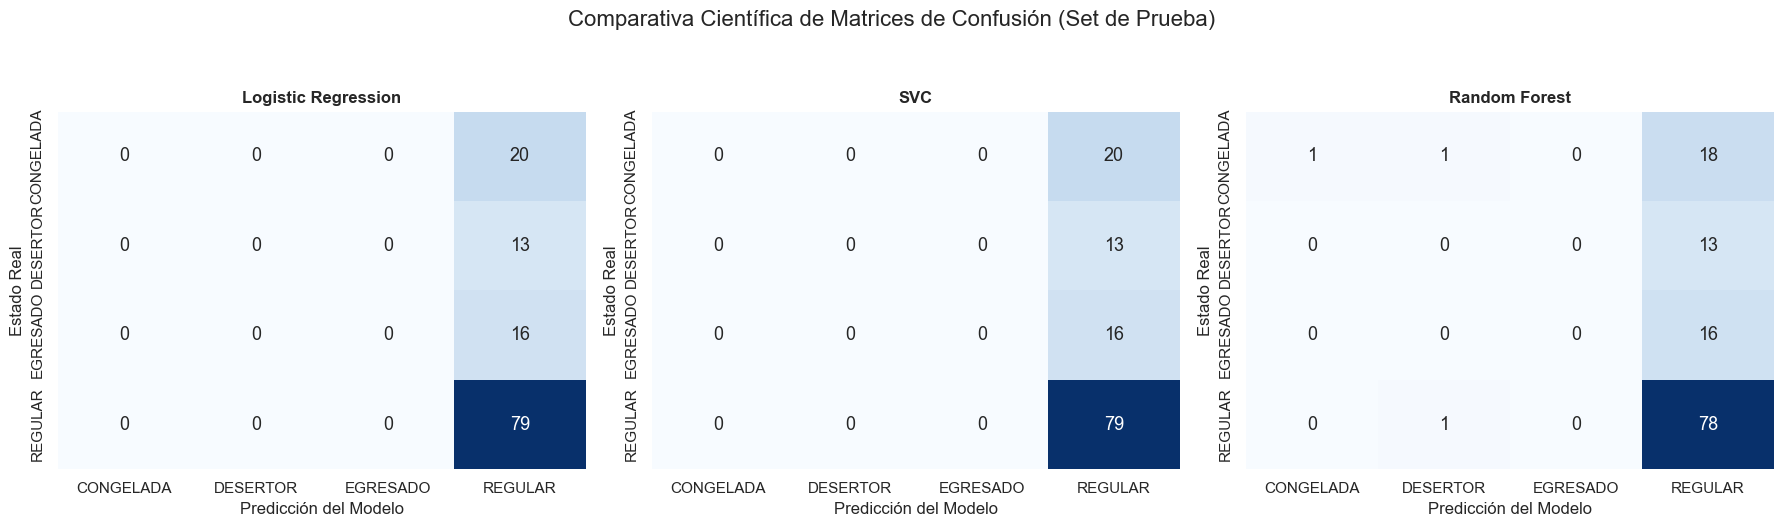

In [6]:
classes = sorted(y.unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparativa Científica de Matrices de Confusión (Set de Prueba)", fontsize=16, y=1.05)

for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[name], labels=classes)
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=False, 
        xticklabels=classes, 
        yticklabels=classes, 
        ax=ax,
        annot_kws={"size": 13}
    )
    
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Predicción del Modelo")
    ax.set_ylabel("Estado Real")

plt.tight_layout()
plt.show()

## 5. Conclusión Técnica y Análisis de Negocio

A partir del marco de experimentación anterior, destacamos los siguientes puntos de inflexión de cara al negocio:

La Paradoja de la Exactitud (Accuracy Paradox): Todos los modelos alcanzan un Accuracy cercano al 62%. Sin embargo, al inspeccionar el Classification Report, evidenciamos que este porcentaje corresponde exactamente a la prevalencia de la clase mayoritaria (REGULAR: 79/128). Los algoritmos base (especialmente Regresión Logística y SVC) no aprendieron a discriminar, sino que optaron por predecir la clase dominante para minimizar su tasa de error global.

Alerta de Desbalance de Clases: La advertencia de Scikit-Learn (UndefinedMetricWarning) ratifica que los modelos ignoraron por completo a las clases minoritarias (DESERTOR, CONGELADA, EGRESADO).

Costo de los Falsos Negativos (Riesgo de Negocio): Actualmente, el Recall para la clase DESERTOR es de 0.00. Esto significa que el 100% de los estudiantes que desertan pasan desapercibidos por el sistema (Falsos Negativos). En un contexto institucional, el costo de no detectar a un alumno vulnerable es inaceptable, ya que impide aplicar protocolos de retención a tiempo.

Siguiente Paso Lógico: El problema no es de falta de correlación, sino de sesgo estadístico por desbalance de clases. En la fase de optimización, será mandatorio penalizar fuertemente a la clase mayoritaria (usando técnicas de balanceo de pesos como class_weight='balanced') para forzar a la máquina a prestar atención a los desertores.